<a href="https://colab.research.google.com/github/majitorom9-bit/Laboratorio-Procesamiento_3/blob/main/Voz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Parte A**

#Importar los audios

In [ ]:
from google.colab import files
files.upload()
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

Saving Mujer-3.wav to Mujer-3 (2).wav
Saving Mujer-2.wav to Mujer-2 (2).wav
Saving Mujer-1.wav to Mujer-1 (2).wav
Saving Hombre-3.wav to Hombre-3 (2).wav
Saving Hombre-2.wav to Hombre-2 (2).wav
Saving Hombre-1.wav to Hombre-1 (2).wav


#Gráfica de las señales

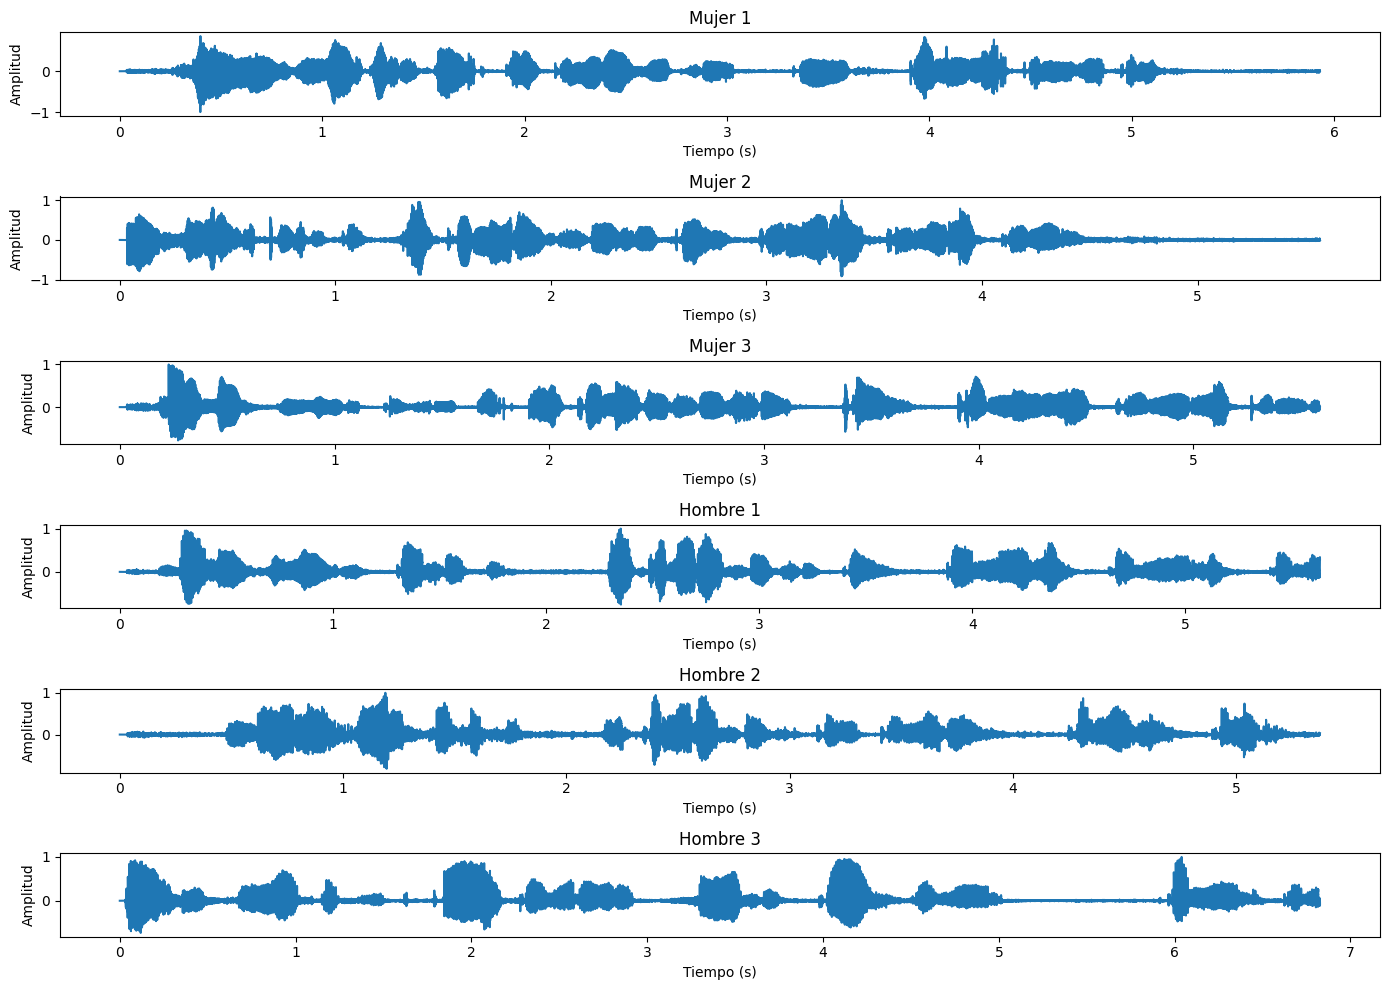

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Cargar audios
fs1, signal1 = wavfile.read('Mujer-1 (2).wav')
fs2, signal2 = wavfile.read('Mujer-2 (2).wav')
fs3, signal3 = wavfile.read('Mujer-3 (2).wav')
fs4, signal4 = wavfile.read('Hombre-1 (2).wav')
fs5, signal5 = wavfile.read('Hombre-2 (2).wav')
fs6, signal6 = wavfile.read('Hombre-3 (2).wav')

# Convertir a mono y normalizar
signals = [signal1, signal2, signal3, signal4, signal5, signal6]
fs = [fs1, fs2, fs3, fs4, fs5, fs6]

for i in range(len(signals)):
    if len(signals[i].shape) > 1:
        signals[i] = signals[i][:,0]
    signals[i] = signals[i] / np.max(np.abs(signals[i]))

# Crear tiempos
tiempos = [np.arange(len(signals[i])) / fs[i] for i in range(6)]

# Graficar
fig, axs = plt.subplots(6,1, figsize=(14,10))

titulos = ["Mujer 1","Mujer 2","Mujer 3","Hombre 1","Hombre 2","Hombre 3"]

for i in range(6):
    axs[i].plot(tiempos[i], signals[i])
    axs[i].set_title(titulos[i])
    axs[i].set_ylabel('Amplitud')
    axs[i].set_xlabel('Tiempo (s)')

plt.tight_layout()
plt.show()

#Transformada de Fourier y espectro de magnitud frecuencial para cada señal

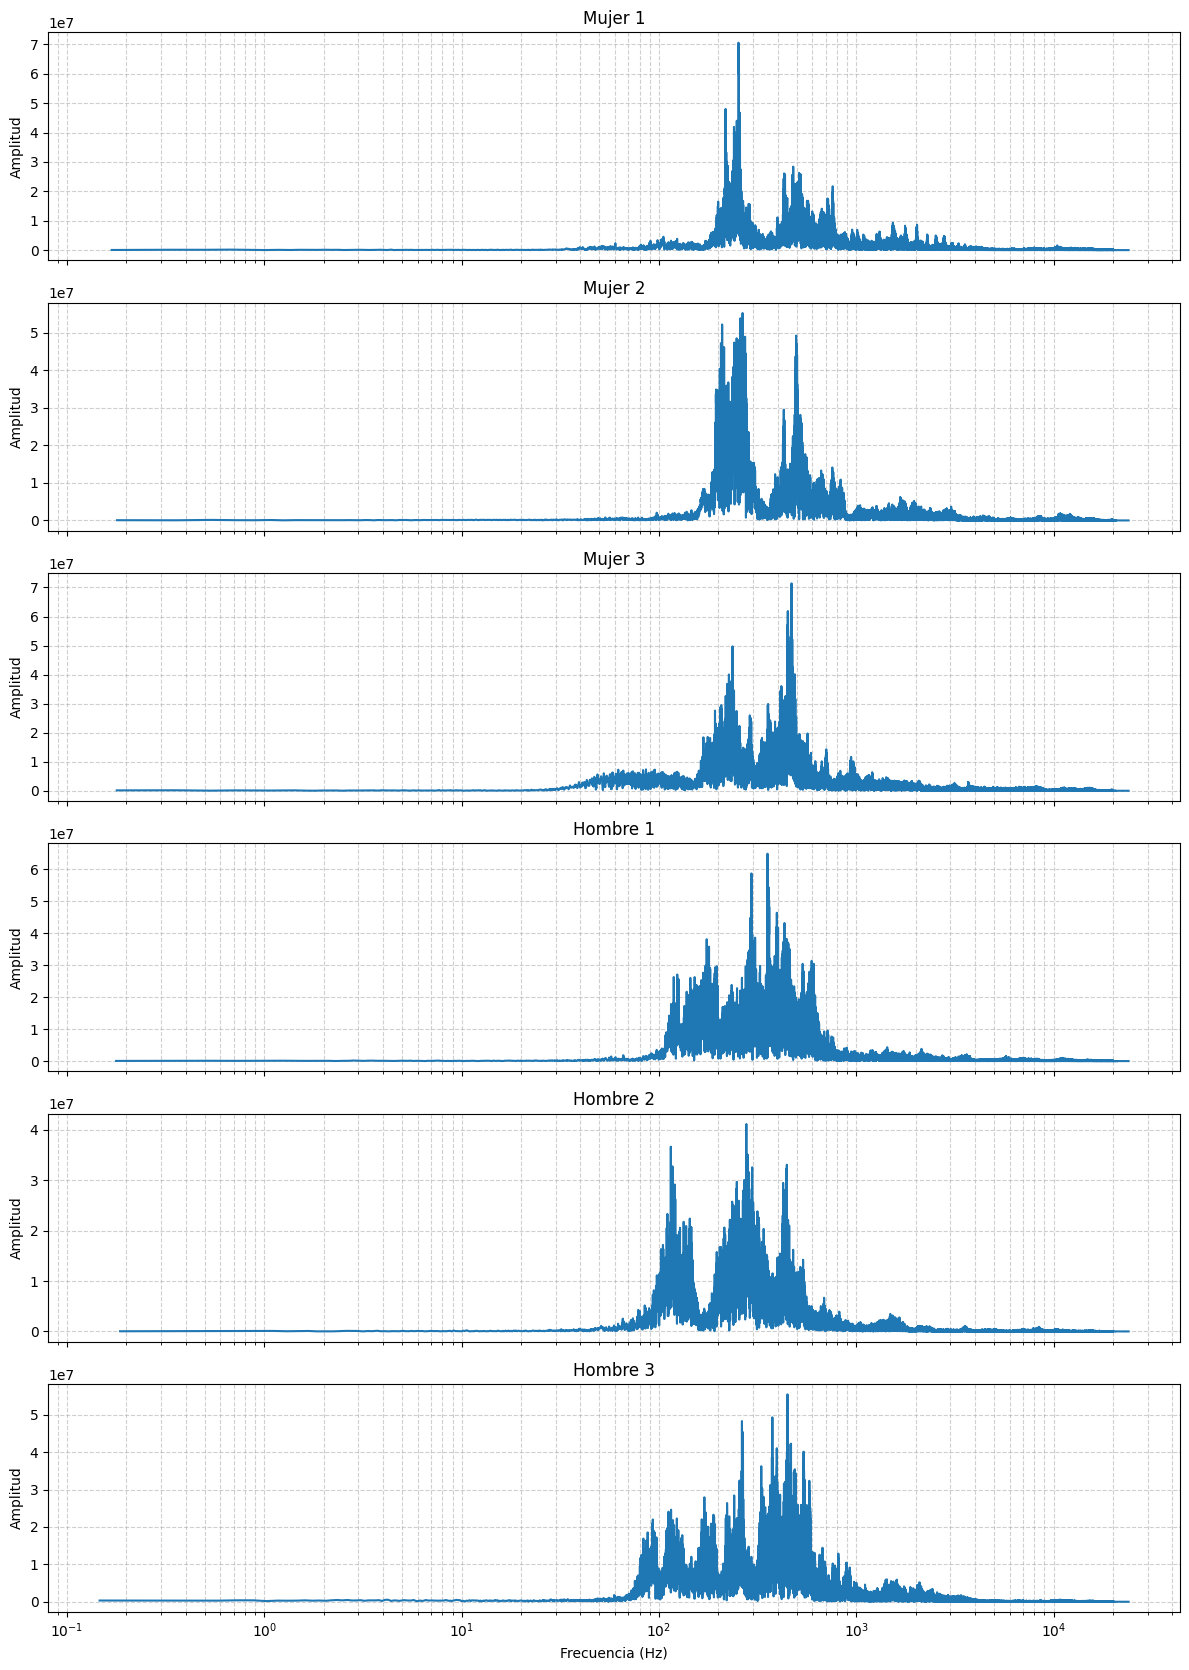

In [ ]:
senales = [
    ("Mujer 1", signal1, fs1),
    ("Mujer 2", signal2, fs2),
    ("Mujer 3", signal3, fs3),
    ("Hombre 1", signal4, fs4),
    ("Hombre 2", signal5, fs5),
    ("Hombre 3", signal6, fs6)
]

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=len(senales), ncols=1,
    figsize=(12, 2.8*len(senales)),
    sharex=True
)

fny_comun = min(fs/2 for _, _, fs in senales)
ymax = 0.0
espectros = []

for (titulo, senal, fs) in senales:
    N = len(senal)
    freqs = np.fft.rfftfreq(N, 1/fs)
    espectro = np.abs(np.fft.rfft(senal))
    idx = freqs <= fny_comun
    espectros.append((titulo, freqs[idx], espectro[idx]))
    ymax = max(ymax, espectro[idx].max())

for ax, (titulo, F, X) in zip(axes, espectros):
    Fp = F[1:]
    Xp = X[1:]
    ax.semilogx(Fp, Xp)
    ax.set_title(titulo)
    ax.set_ylabel('Amplitud')
    ax.grid(True, which='both', linestyle='--', alpha=0.6)
axes[-1].set_xlabel('Frecuencia (Hz)')

fig.tight_layout(); plt.show()


#Características de la señal

In [ ]:
import numpy as np
import pandas as pd
from numpy.fft import rfft, rfftfreq
from scipy.signal import find_peaks


def _to_mono_float(x):
    x = np.asarray(x)
    if x.ndim > 1:
        x = x.mean(axis=1)
    x = x.astype(np.float32)
    x = x - x.mean()
    return x

def analizar_senal(signal, fs):
    sig = _to_mono_float(signal)
    N = len(sig)
    if N == 0 or fs <= 0:
        return 0.0, 0.0, 0.0, 0.0

    X = np.abs(rfft(sig))
    f = rfftfreq(N, d=1.0/fs)

    #Frecuencia fundamental
    mask = f >= 50.0
    Xb = X[mask]
    fb = f[mask]
    if Xb.size and Xb.max() > 0:
        peaks, _ = find_peaks(Xb, height=0.10 * Xb.max())
        if peaks.size:
            f0 = float(fb[peaks[np.argmax(Xb[peaks])]])  #Pico más alto
        else:
            f0 = 0.0
    else:
        f0 = 0.0

    #Frecuencia media
    denom = X.sum()
    f_media = float((f * X).sum() / denom) if denom > 0 else 0.0

    #Brillo
    E_total = float((X**2).sum())
    E_altas = float((X[f > 1500.0]**2).sum())
    brillo = float(E_altas / E_total) if E_total > 0 else 0.0

    #Intensidad
    intensidad = float((sig**2).mean())

    return f0, f_media, brillo, intensidad

nombres = ["Mujer 1","Mujer 2","Mujer 3","Hombre 1","Hombre 2","Hombre 3"]
senales = [signal1, signal2, signal3, signal4, signal5, signal6]
fs_list = [fs1, fs2, fs3, fs4, fs5, fs6]

resultados = []
for nom, sig, fs in zip(nombres, senales, fs_list):
    f0, fmedia, brillo, intensidad = analizar_senal(sig, fs)
    resultados.append([nom, f0, fmedia, brillo, intensidad])

tabla = pd.DataFrame(resultados, columns=["Señal","f0 (Hz)","f_media (Hz)","Brillo","Intensidad"])
print(tabla.to_string(index=False))

   Señal    f0 (Hz)  f_media (Hz)   Brillo  Intensidad
 Mujer 1 253.259892   3731.791957 0.089506  10203768.0
 Mujer 2 265.625000   3660.250096 0.051551  16567467.0
 Mujer 3 470.181298   3690.630463 0.036946  17939960.0
Hombre 1 355.291193   2735.577073 0.017587  20006824.0
Hombre 2 277.529762   2317.599295 0.011562   9058843.0
Hombre 3 448.535156   1982.546529 0.029201  14756064.0


#**Parte B**

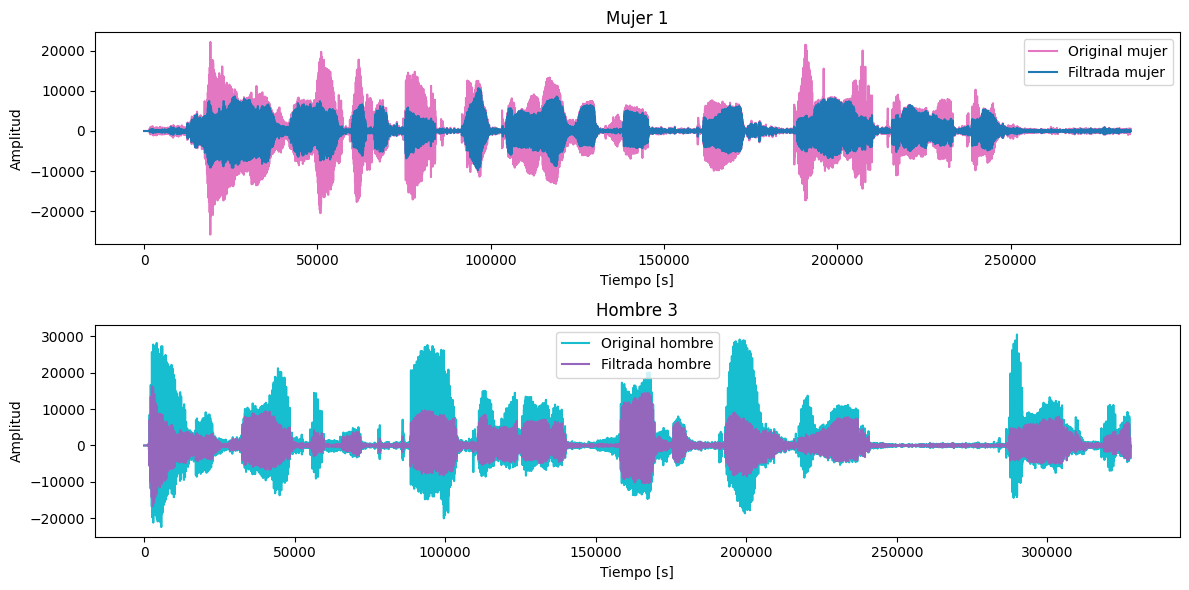

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

def filtro_pasabanda(x, fs, lowcut, highcut):
  nyq = 0.5 * fs
  low= lowcut/ nyq
  high = highcut / nyq
  b, a= butter(4, [low, high], btype='band')
  return filtfilt(b, a, x)

mujer1_filtrada= filtro_pasabanda(signal1, fs3, 150, 500)

hombre3_filtrada= filtro_pasabanda(signal6, fs6, 80, 400)

plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(signal1, color='tab:pink', label="Original mujer")
plt.plot(mujer1_filtrada, color='tab:blue', label="Filtrada mujer")
plt.title("Mujer 1")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()

plt.subplot(2,1,2)
plt.plot(signal6, color='tab:cyan', label="Original hombre")
plt.plot(hombre3_filtrada, color='tab:purple', label="Filtrada hombre")
plt.title("Hombre 3")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()

plt.tight_layout()
plt.show()